In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [23]:
data = pd.DataFrame({
    "x": [1, 1.5, 2, 8, 8.5, 9],
    "y": [1, 2, 1.5, 8, 9, 8.5]
})


In [24]:

data

,x,y
0,1.0,1.0
1,1.5,2.0
2,2.0,1.5
3,8.0,8.0
4,8.5,9.0
5,9.0,8.5


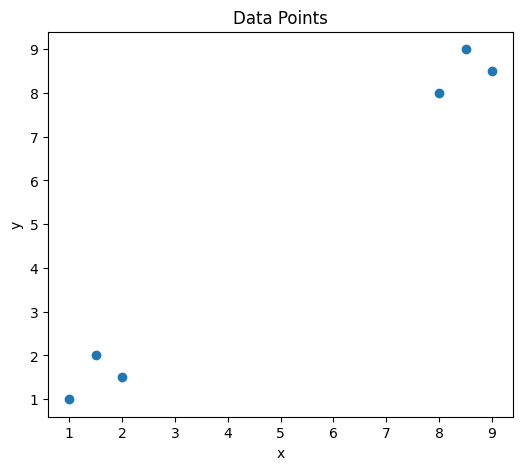

In [25]:
plt.figure(figsize=(6, 5))

plt.scatter(data["x"], data["y"])

plt.xlabel("x")
plt.ylabel("y")
plt.title("Data Points")


plt.show()


In [26]:
points = data[["x","y"]].values
points

array([[1. , 1. ],
       [1.5, 2. ],
       [2. , 1.5],
       [8. , 8. ],
       [8.5, 9. ],
       [9. , 8.5]])

In [27]:
k = 2
np.random.seed(42)

random_indices = np.random.choice(len(points), size=k, replace=False)
centroids = points[random_indices]

centroids

array([[1. , 1. ],
       [1.5, 2. ]])

In [28]:
def assign_clusters(points, centroids):
    clusters=[]

    for point in points:
        distances = []

        for centroid in centroids:
            distance = np.sqrt(np.sum((point - centroid) ** 2))
            distances.append(distance)

        closest_cluster = np.argmin(distances)
        clusters.append(closest_cluster)

    return np.array(clusters)

In [29]:
def update_centroids(points, clusters, k):
    new_centroids = []

    for cluster_id in range(k):
        cluster_points = points[clusters == cluster_id]
        new_centroid = cluster_points.mean(axis=0)
        new_centroids.append(new_centroid)

    return np.array(new_centroids)

In [30]:
for i in range(10):
    clusters = assign_clusters(points, centroids)
    new_centroids = update_centroids(points, clusters, k)

    if np.allclose(centroids, new_centroids):
        break

    centroids = new_centroids

clusters, centroids

(array([0, 0, 0, 1, 1, 1]),
 array([[1.5, 1.5],
        [8.5, 8.5]]))